In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [5]:
x,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [8]:
df=pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.822186,-0.475545,0.682555,0.626556,-2.153727,0
1,-0.902269,0.619074,-0.835563,0.988047,-2.046745,1
2,1.585729,-1.979863,3.747974,-1.636240,0.051351,0
3,-0.347761,0.627682,-0.667017,1.393434,-0.827514,1
4,1.013018,-1.877981,3.405479,-1.037532,-2.164290,0


In [9]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [11]:
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df=df[cols].copy()
    new_df['target']=df['target']
    return new_df

In [12]:
def combined_sampling(df,row_percent,col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [13]:
df1=combined_sampling(df,0.5,0.5)

In [14]:
df2=combined_sampling(df,0.5,0.5)

In [15]:
df3=combined_sampling(df,0.5,0.5)

In [16]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='str')
Index(['col5', 'col2', 'target'], dtype='str')
Index(['col2', 'col5', 'target'], dtype='str')


In [18]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [19]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9, 'x[0] <= 0.117\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.3, 0.7, 'x[1] <= -2.823\ngini = 0.074\nsamples = 26\nvalue = [25, 1]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[1] <= -3.547\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 24\nvalue = [24, 0]'),
 Text(0.7, 0.7, 'x[1] <= -1.681\ngini = 0.153\nsamples = 24\nvalue = [2, 22]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'x[0] <= 0.219\ngini = 0.083\nsamples = 23\nvalue = [1, 22]'),
 Text(0.7, 0.3, 'x[0] <= 0.13\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]')]

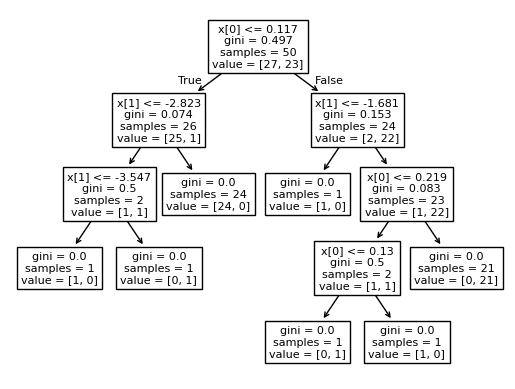

In [21]:
plot_tree(clf1)

[Text(0.4642857142857143, 0.9285714285714286, 'x[1] <= 0.211\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.21428571428571427, 0.7857142857142857, 'x[1] <= -3.188\ngini = 0.185\nsamples = 29\nvalue = [26, 3]'),
 Text(0.3392857142857143, 0.8571428571428572, 'True  '),
 Text(0.14285714285714285, 0.6428571428571429, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2857142857142857, 0.6428571428571429, 'x[0] <= -2.158\ngini = 0.133\nsamples = 28\nvalue = [26, 2]'),
 Text(0.21428571428571427, 0.5, 'x[0] <= -2.331\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.14285714285714285, 0.35714285714285715, 'x[0] <= -3.2\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.07142857142857142, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.21428571428571427, 0.21428571428571427, 'x[0] <= -2.992\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.14285714285714285, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.28571428571428

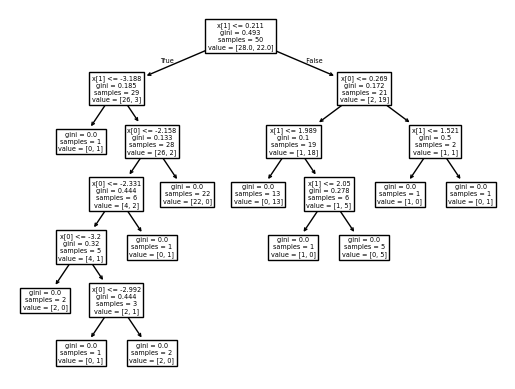

In [22]:
plot_tree(clf2)

[Text(0.45454545454545453, 0.9444444444444444, 'x[0] <= -0.347\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.18181818181818182, 0.8333333333333334, 'x[1] <= 1.439\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.3181818181818182, 0.8888888888888888, 'True  '),
 Text(0.09090909090909091, 0.7222222222222222, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.2727272727272727, 0.7222222222222222, 'x[0] <= -1.163\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.18181818181818182, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.36363636363636365, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7272727272727273, 0.8333333333333334, 'x[1] <= 1.308\ngini = 0.404\nsamples = 32\nvalue = [9, 23]'),
 Text(0.5909090909090909, 0.8888888888888888, '  False'),
 Text(0.6363636363636364, 0.7222222222222222, 'x[1] <= -0.894\ngini = 0.328\nsamples = 29\nvalue = [6, 23]'),
 Text(0.5454545454545454, 0.6111111111111112, 'x[0] <= 0.087\ng

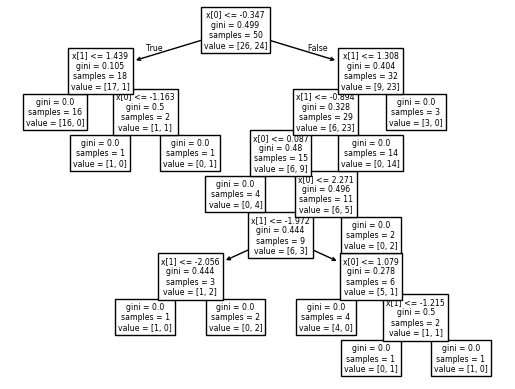

In [23]:
plot_tree(clf3)

In [26]:
clf1.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [27]:
clf2.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [28]:
clf3.predict(np.array([-1.042498,-0.064323]).reshape(1,2))

C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])